Un experimento puso en marcha 50 turbinas durante distintos intervalos de tiempo. Se registró
la proporción de turbinas que desarrollaban fisuras durante cada prueba. Los datos están en el
archivo turbines.csv .
Estadística e inferencia I — Segundo Cuatrimestre — 2024
- (a) Graficar la proporción de turbinas con fisuras vs la cantidad de horas de cada prueba. Justificar por qué un MLG binomial es una opción razonable para modelar la dependencia de
la fracción de turbinas con fisuras respecto a la cantidad de horas. Proponer una función de
vínculo.
- (b) Ajustar este MLG binomial, es decir, encontrar estimaciones p-untuales para los parámetros
de regresión 𝛽 justificando cada paso.

- (c) Determinar el error estándar de cada parámetro de regresión justificando cada paso

In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [16]:
path = './turbines.csv'
df = pd.read_csv(path)

In [17]:
df.head()

,Hours,Proportions of Fissures
0,400,0.0000
1,1000,0.0755
2,1400,0.0606
3,1800,0.0959
4,2200,0.1667


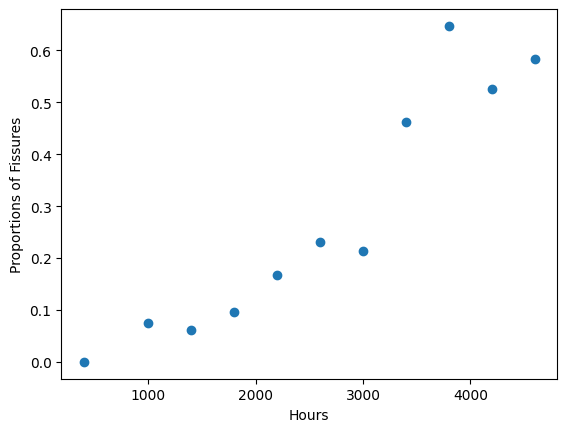

In [18]:
plt.scatter(df['Hours'],df["Proportions of Fissures"])
plt.xlabel('Hours')
plt.ylabel('Proportions of Fissures')
plt.show()


La proporcion de fisuras esta limimtada entre 0 y 1, o sea puede o no tener fallos como funcion de vinculo propongo:

In [19]:
def logit(p):
    return np.log(p / (1 - p))


In [20]:

from scipy.optimize import minimize

# Definir la función de verosimilitud para el modelo logit
def logit_likelihood(params, y, x):
    p = 1 / (1 + np.exp(-(params[0] + params[1] * x))) # formula: p = 1 / (1 + exp(-β0 - β1 * x))
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p)) # formula : -Σ(y * log(p) + (1 - y) * log(1 - p))

X,Y = df["Hours"], df["Proportions of Fissures"]

intercept = np.ones(X.shape)
X_with_intercept = np.column_stack((intercept,X))



initial_beta = np.zeros(X_with_intercept.shape[1])
res_bi = minimize(logit_likelihood, initial_beta, args=(X_with_intercept, Y))


b0 = res_bi.x[0]
b1 = res_bi.x[1]
print('b0 = ', b0)
print('b1 = ', b1)





ValueError: operands could not be broadcast together with shapes (11,2) (11,) 

In [21]:
# 
# Ajustar el modelo por máxima verosimilitud
from scipy.optimize import minimize


# Definir la función de verosimilitud para el modelo logit
def logit_likelihood(params, y, x):
    p = 1 / (1 + np.exp(-(params[0] + params[1] * x))) # formula: p = 1 / (1 + exp(-β0 - β1 * x))
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p)) # formula : -Σ(y * log(p) + (1 - y) * log(1 - p))

initial_params = np.array([0, 0])

result = minimize(logit_likelihood, initial_params, args=(df['Proportions of Fissures'], df['Hours']))

# Obtener los parámetros estimados
beta_0, beta_1 = result.x
print(f"Estimaciones paraa  los parámetros de regresión: β0 = {beta_0}, β1 = {beta_1}")


Estimaciones paraa  los parámetros de regresión: β0 = -3.9110434637671903, β1 = 0.0010110061505002308


c:\Users\lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\optimize\_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
c:\Users\lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
